In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/gpiosenka/sports-classification/EfficientNetB0-100-(224 X 224)- 98.40.h5
/kaggle/input/datasets/gpiosenka/sports-classification/sports.csv
/kaggle/input/datasets/gpiosenka/sports-classification/valid/bobsled/5.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/bobsled/1.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/bobsled/4.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/bobsled/3.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/bobsled/2.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/hurdles/5.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/hurdles/1.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/hurdles/4.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/hurdles/3.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/hurdles/2.jpg
/kaggle/input/datasets/gpiosenka/sports-classification/valid/snow boarding/5.jpg
/kaggle

In [2]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
import os

DATASET_PATH = "/kaggle/input/datasets/gpiosenka/sports-classification"

print("Dataset Contents:")
print(os.listdir(DATASET_PATH))

print("\nTraining Folder:")
print(os.listdir(os.path.join(DATASET_PATH, "train"))[:10])

print("\nValidation Folder:")
print(os.listdir(os.path.join(DATASET_PATH, "valid"))[:10])

print("\nTest Folder:")
print(os.listdir(os.path.join(DATASET_PATH, "test"))[:10])

Dataset Contents:
['EfficientNetB0-100-(224 X 224)- 98.40.h5', 'sports.csv', 'valid', 'test', 'train']

Training Folder:
['bobsled', 'hurdles', 'snow boarding', 'fly fishing', 'luge', 'sidecar racing', 'ampute football', 'volleyball', 'billiards', 'giant slalom']

Validation Folder:
['bobsled', 'hurdles', 'snow boarding', 'fly fishing', 'luge', 'sidecar racing', 'ampute football', 'volleyball', 'billiards', 'giant slalom']

Test Folder:
['bobsled', 'hurdles', 'snow boarding', 'fly fishing', 'luge', 'sidecar racing', 'ampute football', 'volleyball', 'billiards', 'giant slalom']


In [4]:
import os
import pandas as pd

train_path = os.path.join(DATASET_PATH, "train")
valid_path = os.path.join(DATASET_PATH, "valid")
test_path = os.path.join(DATASET_PATH, "test")

num_classes = len(os.listdir(train_path))

train_images = sum(len(files) for _, _, files in os.walk(train_path))
valid_images = sum(len(files) for _, _, files in os.walk(valid_path))
test_images = sum(len(files) for _, _, files in os.walk(test_path))

dataset_table = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Images": [train_images, valid_images, test_images]
})

print("Number of Classes:", num_classes)
display(dataset_table)

Number of Classes: 100


,Dataset,Images
0,Training,13493
1,Validation,500
2,Testing,500


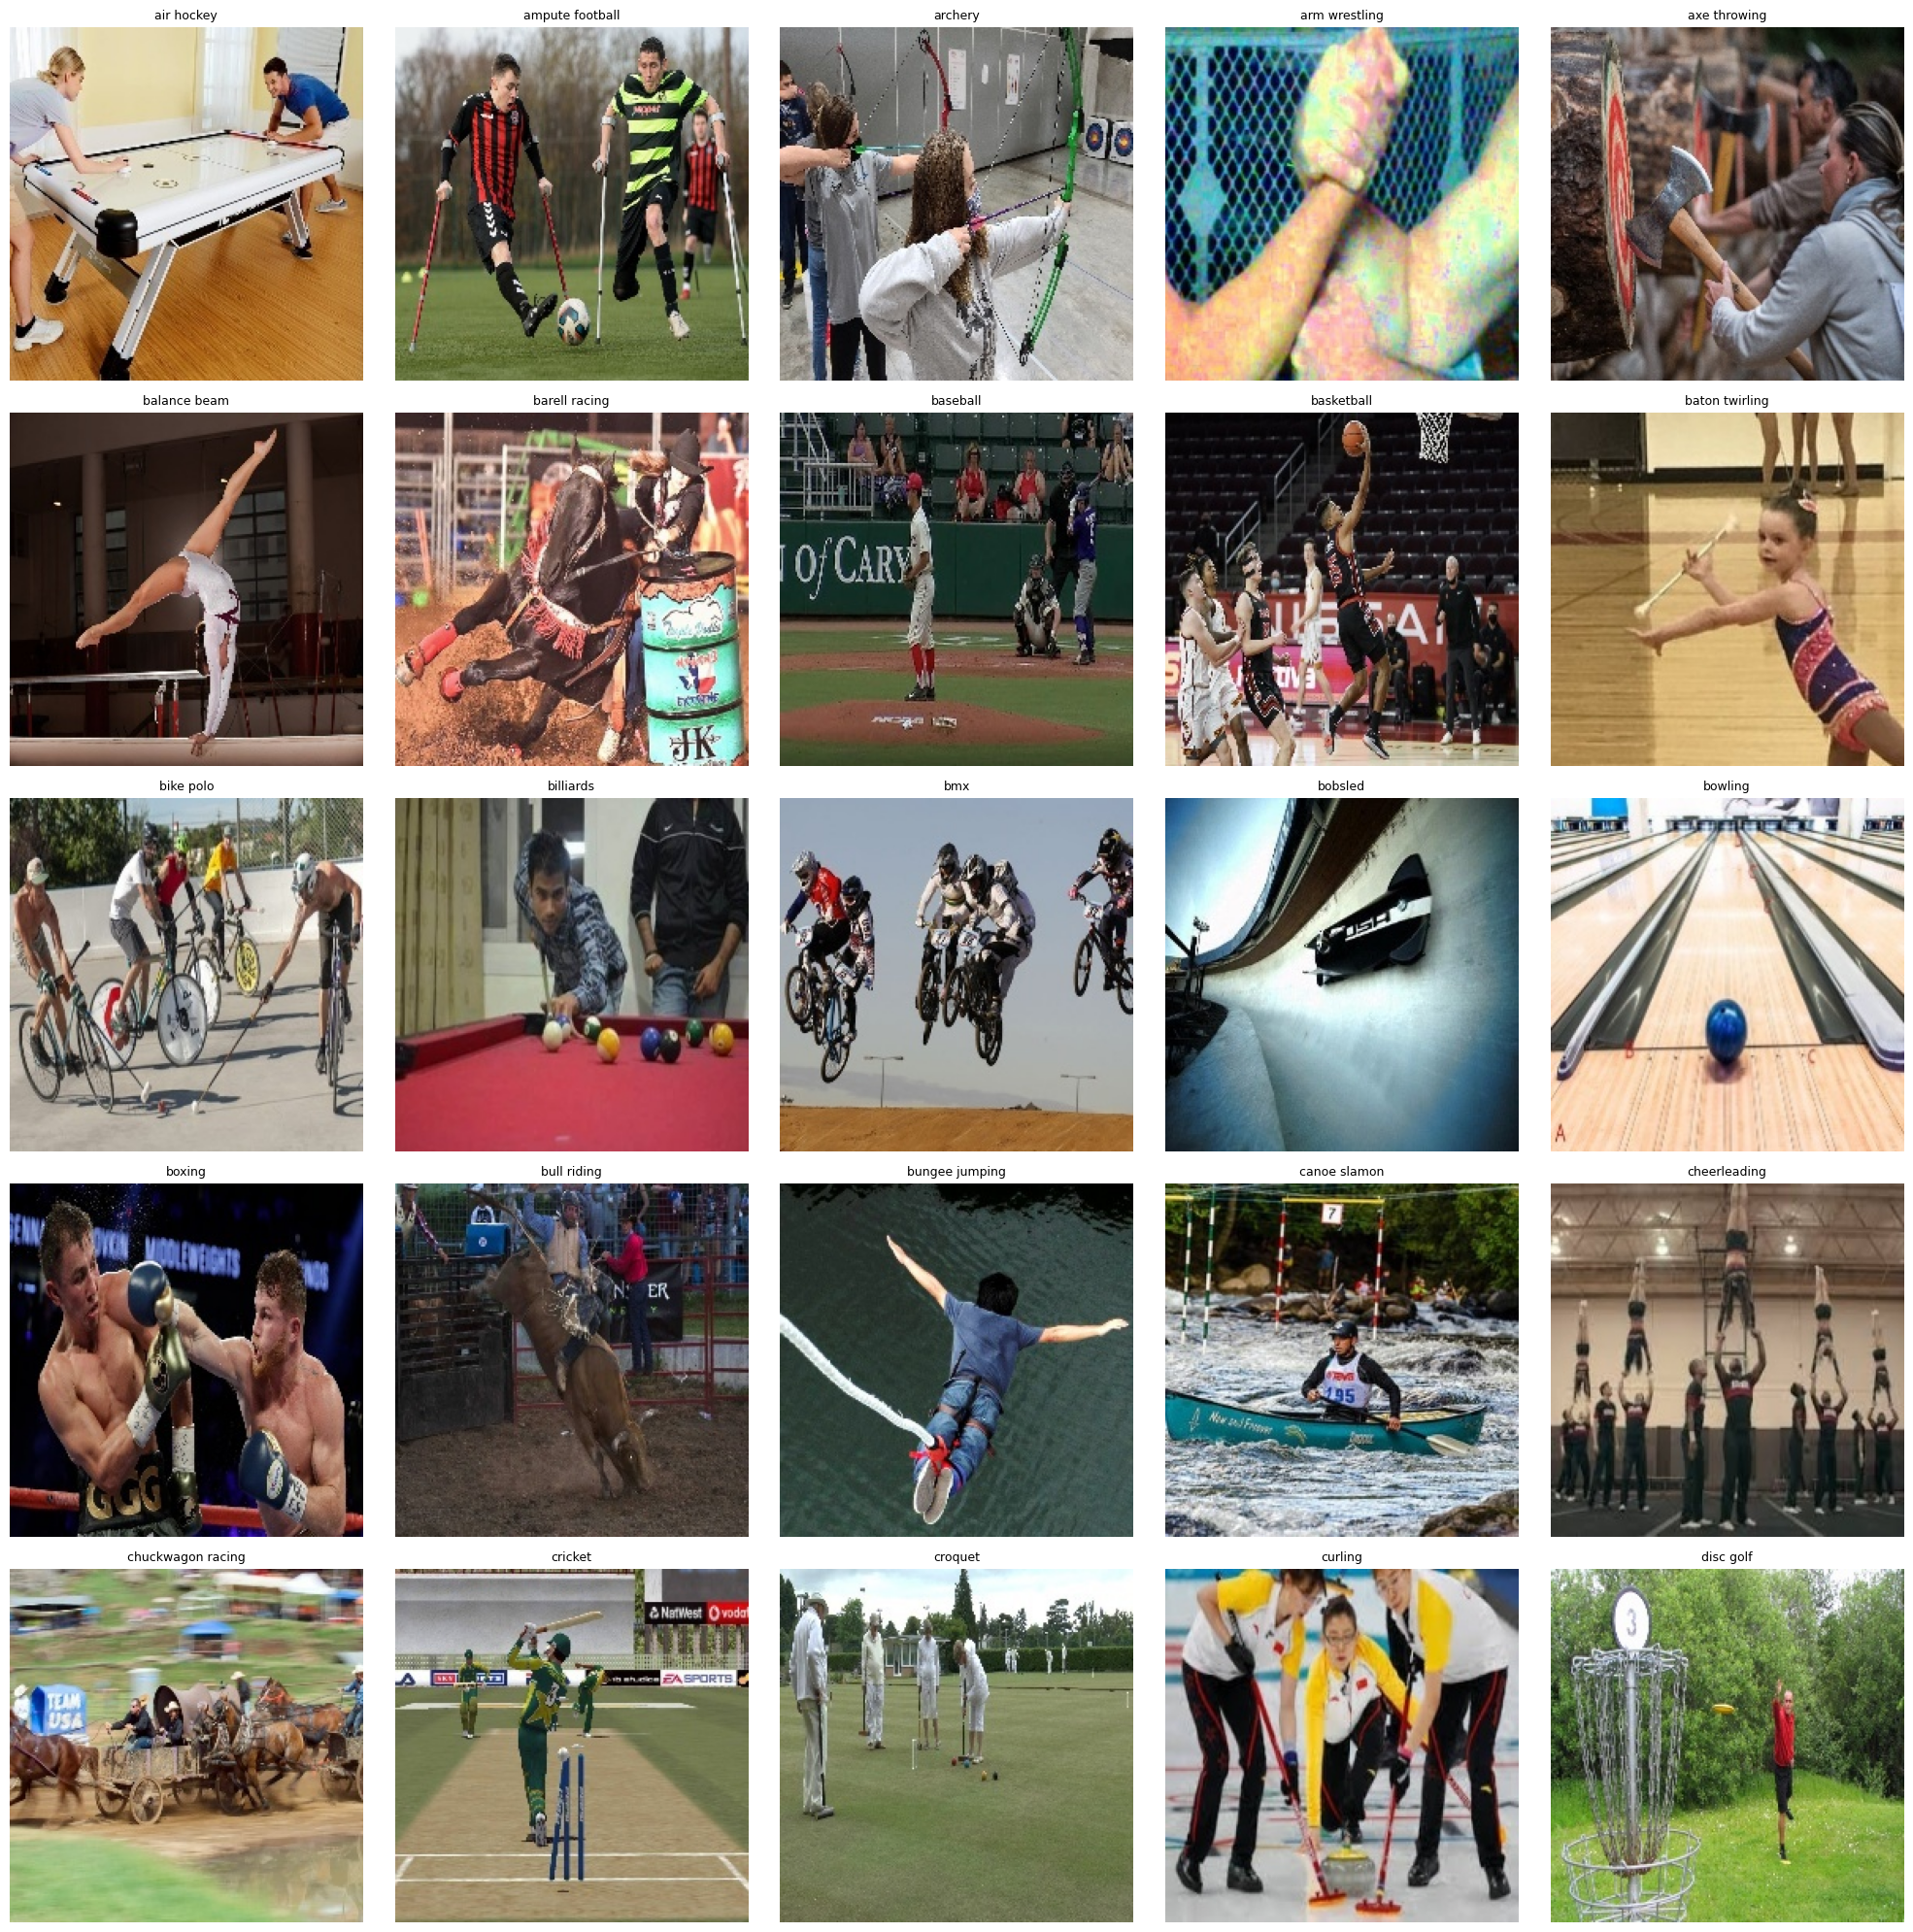

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import random

train_path = os.path.join(DATASET_PATH, "train")

classes = sorted(os.listdir(train_path))

plt.figure(figsize=(20,20))

for i, class_name in enumerate(classes[:25]):   # Display first 25 classes
    class_folder = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_name)

    img = Image.open(img_path)

    plt.subplot(5,5,i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

class_names = sorted(os.listdir(train_path))
image_counts = []

for cls in class_names:
    image_counts.append(len(os.listdir(os.path.join(train_path, cls))))

distribution_df = pd.DataFrame({
    "Class": class_names,
    "Images": image_counts
})

distribution_df.head()

,Class,Images
0,air hockey,112
1,ampute football,112
2,archery,132
3,arm wrestling,99
4,axe throwing,113


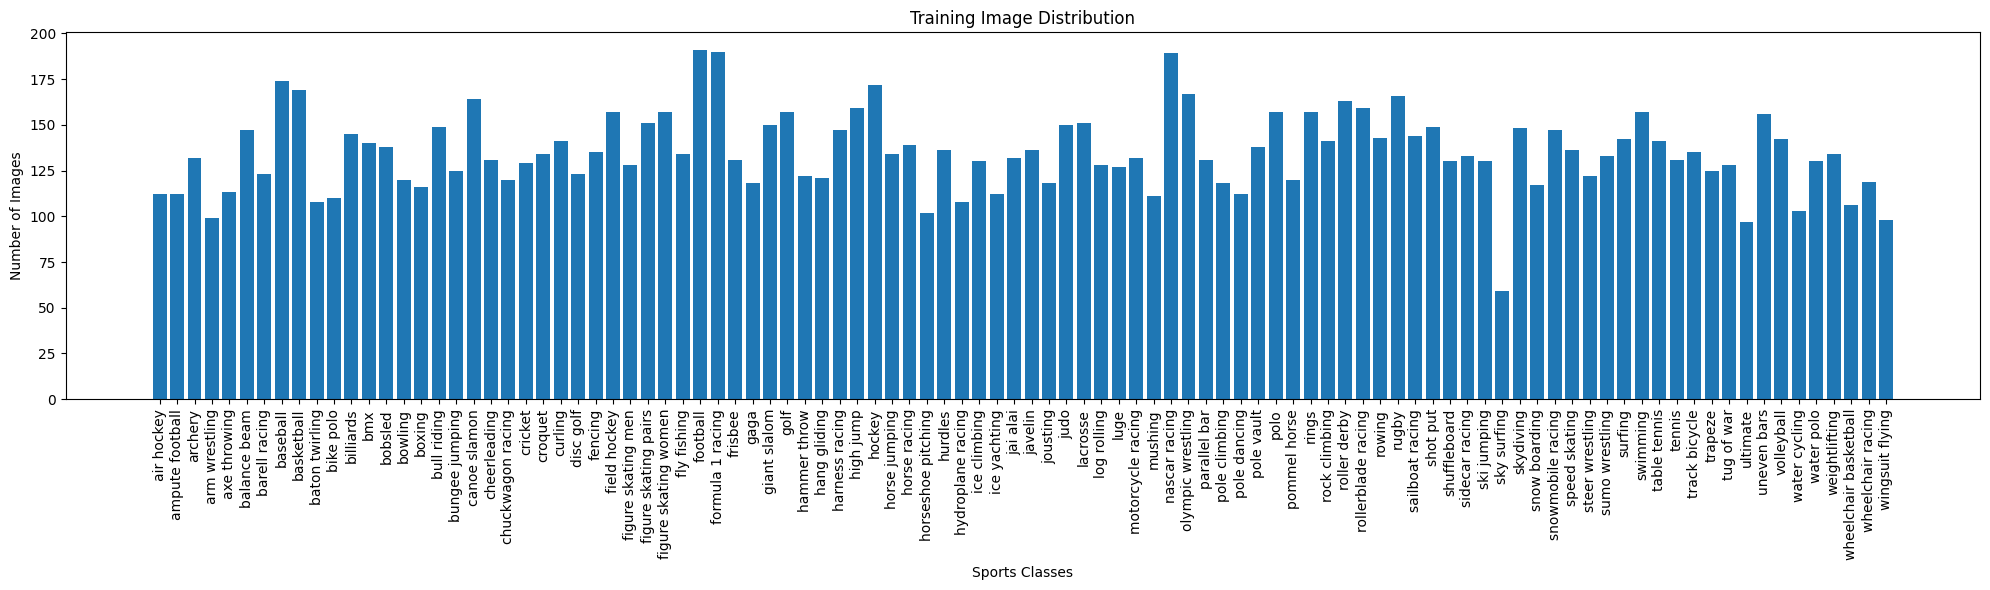

In [7]:
plt.figure(figsize=(20,6))
plt.bar(distribution_df["Class"], distribution_df["Images"])
plt.xticks(rotation=90)
plt.xlabel("Sports Classes")
plt.ylabel("Number of Images")
plt.title("Training Image Distribution")
plt.tight_layout()
plt.show()

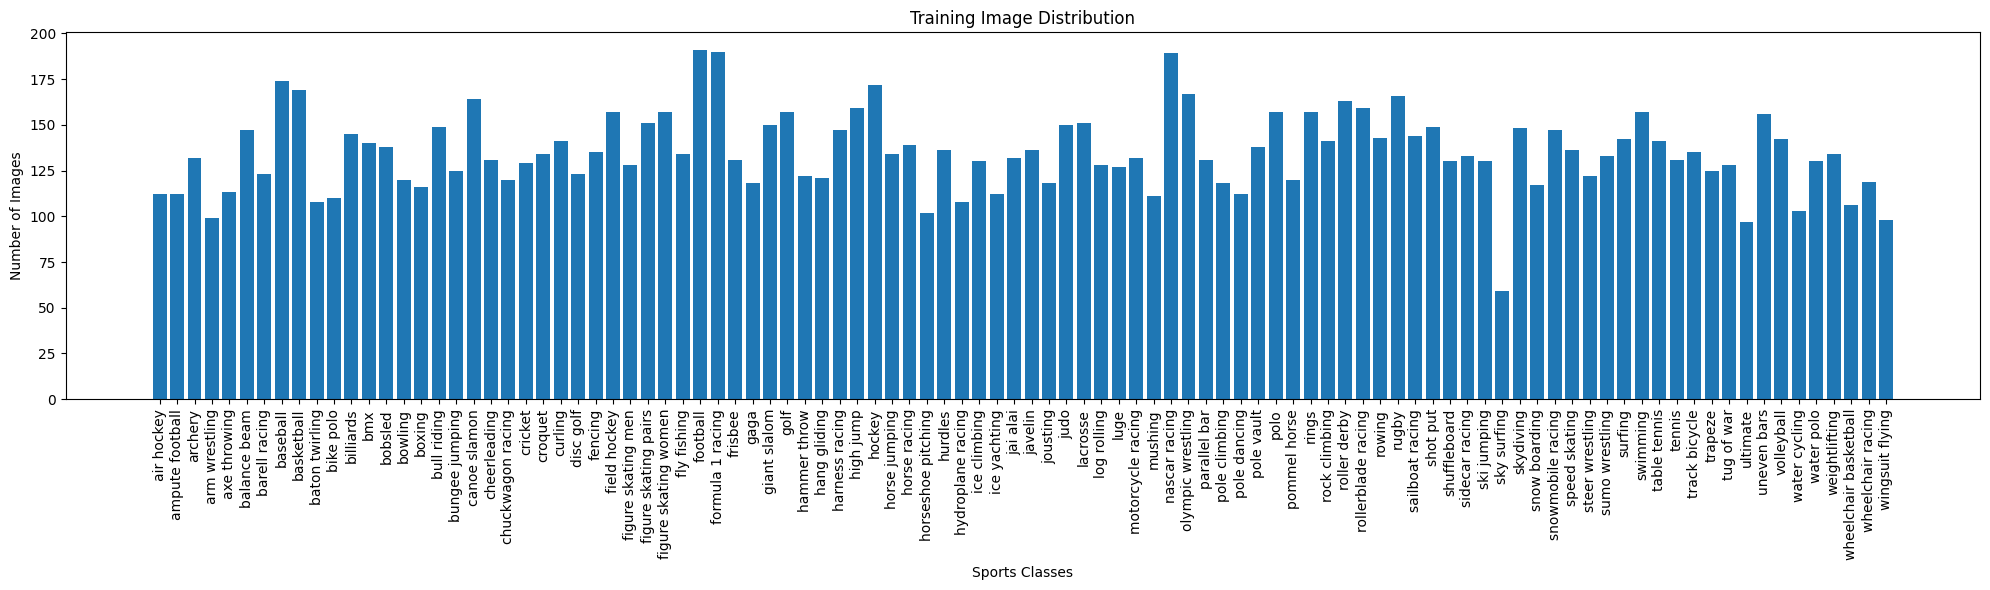

In [8]:
plt.figure(figsize=(20,6))
plt.bar(distribution_df["Class"], distribution_df["Images"])
plt.xticks(rotation=90)
plt.xlabel("Sports Classes")
plt.ylabel("Number of Images")
plt.title("Training Image Distribution")
plt.tight_layout()

plt.savefig("dataset_distribution.png", dpi=300)
plt.show()


In [9]:
import os

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [10]:
dataset_table.to_csv("tables/dataset_statistics.csv", index=False)

dataset_table

,Dataset,Images
0,Training,13493
1,Validation,500
2,Testing,500


In [11]:
distribution_df.to_csv("tables/class_distribution.csv", index=False)

distribution_df.head()

,Class,Images
0,air hockey,112
1,ampute football,112
2,archery,132
3,arm wrestling,99
4,axe throwing,113


In [12]:
plt.tight_layout()

plt.savefig("figures/sample_images.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 640x480 with 0 Axes>

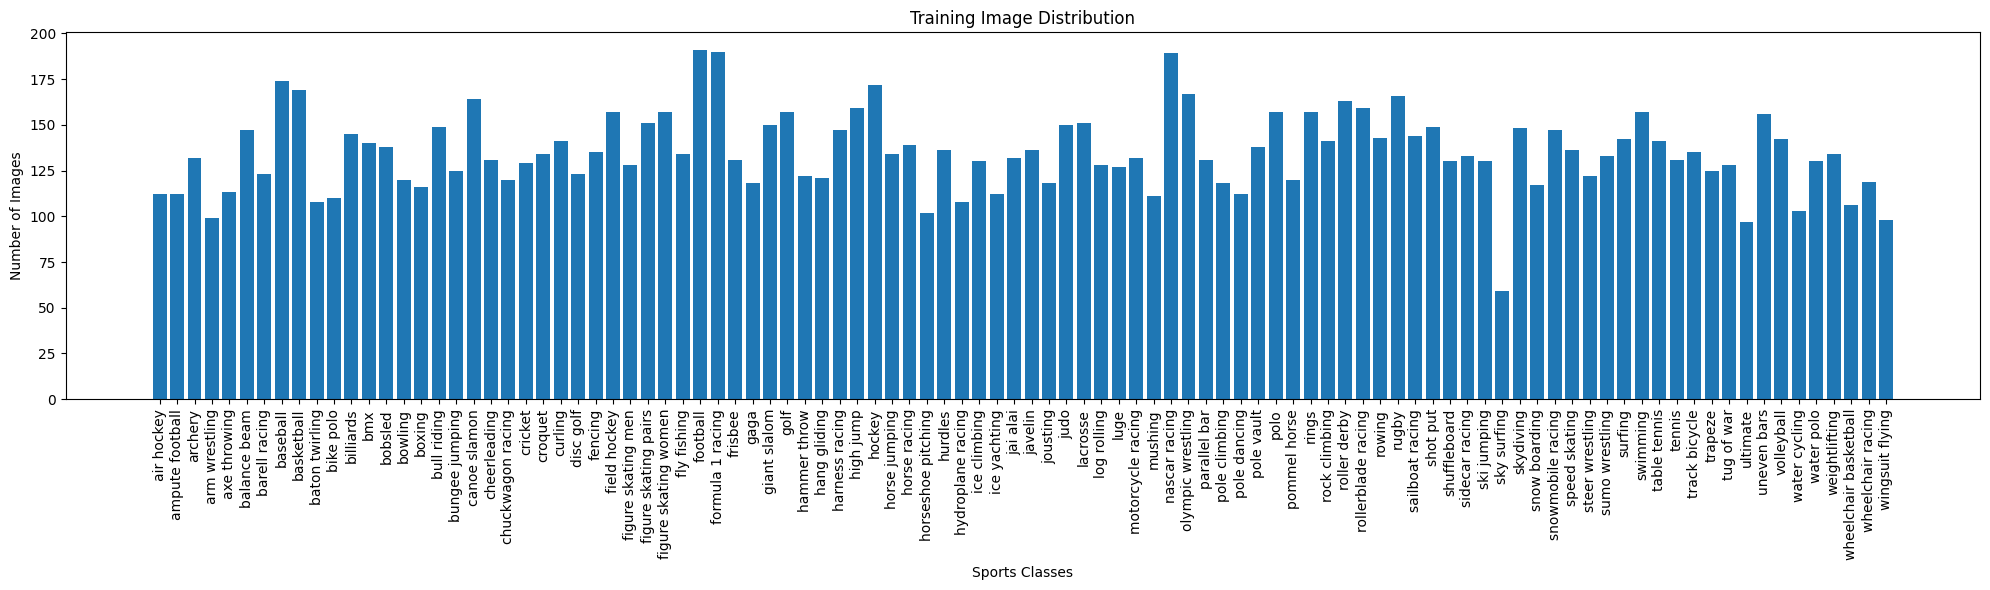

In [13]:
plt.figure(figsize=(20,6))

plt.bar(distribution_df["Class"],
        distribution_df["Images"])

plt.xticks(rotation=90)

plt.xlabel("Sports Classes")

plt.ylabel("Number of Images")

plt.title("Training Image Distribution")

plt.tight_layout()

plt.savefig("figures/dataset_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_path = "/kaggle/input/datasets/gpiosenka/sports-classification/train"
valid_path = "/kaggle/input/datasets/gpiosenka/sports-classification/valid"
test_path  = "/kaggle/input/datasets/gpiosenka/sports-classification/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = valid_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

2026-07-01 09:46:38.406807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782899198.426793     113 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782899198.432676     113 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782899198.450894     113 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782899198.450941     113 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782899198.450944     113 computation_placer.cc:177] computation placer alr

Found 13492 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.


In [15]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20
)

NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights=None,
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(100, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
plt.plot(history.history['accuracy'])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.savefig("figures/accuracy_curve.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.savefig("figures/loss_curve.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
import numpy as np

test_generator.reset()

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(15,15))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

plt.savefig("figures/confusion_matrix.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

In [ ]:
plt.savefig("figures/accuracy_curve.png", dpi=300, bbox_inches="tight")

In [ ]:
plt.savefig("figures/loss_curve.png", dpi=300, bbox_inches="tight")

In [ ]:
plt.savefig("figures/confusion_matrix.png", dpi=300, bbox_inches="tight")

In [ ]:
import os

if os.path.exists("/kaggle/working/Sports_Project_Outputs.zip"):
    os.remove("/kaggle/working/Sports_Project_Outputs.zip")

print("Old zip deleted.")

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    for file in files:
        path = os.path.join(root, file)
        size = os.path.getsize(path)/(1024*1024)
        print(f"{size:.2f} MB  {path}")

In [ ]:
import zipfile
import os

with zipfile.ZipFile("/kaggle/working/Project_Outputs.zip", "w") as z:
    for folder in ["figures", "tables"]:
        folder_path = f"/kaggle/working/{folder}"
        if os.path.exists(folder_path):
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    z.write(file_path, os.path.relpath(file_path, "/kaggle/working"))

print("ZIP created successfully!")

In [ ]:
model.save("/kaggle/working/sports_model.keras")

In [ ]:
import zipfile
import os

with zipfile.ZipFile("/kaggle/working/Project_Outputs.zip", "w") as z:
    for folder in ["figures", "tables"]:
        folder_path = f"/kaggle/working/{folder}"
        if os.path.exists(folder_path):
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    z.write(file_path, os.path.relpath(file_path, "/kaggle/working"))

    if os.path.exists("/kaggle/working/sports_model.keras"):
        z.write("/kaggle/working/sports_model.keras", "sports_model.keras")

print("Done!")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/figures/accuracy_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/figures/loss_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
plt.figure(figsize=(12,10))

# your confusion matrix plotting code here

plt.savefig("/kaggle/working/figures/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot([1,2,3,4,5],[2,4,6,8,10], marker='o')
plt.title("Test Graph")
plt.xlabel("X")
plt.ylabel("Y")

plt.savefig("/kaggle/working/test_graph.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import os

files = [
    "/kaggle/working/figures/accuracy_curve.png",
    "/kaggle/working/figures/loss_curve.png",
    "/kaggle/working/figures/confusion_matrix.png"
]

for file in files:
    if os.path.exists(file):
        os.remove(file)
        print(f"Deleted: {file}")
    else:
        print(f"Not found: {file}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/figures/accuracy_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/figures/loss_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
plt.close()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(18,18))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=90)

plt.savefig("/kaggle/working/figures/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()
plt.close()

In [ ]:
import os

for f in [
    "/kaggle/working/figures/accuracy_curve.png",
    "/kaggle/working/figures/loss_curve.png",
    "/kaggle/working/figures/confusion_matrix.png",
]:
    print(f, "Exists" if os.path.exists(f) else "Missing")

In [ ]:
from PIL import Image

img = Image.open("/kaggle/working/figures/accuracy_curve.png")
print(img.size)
display(img)

In [ ]:
print(globals().keys())

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/sports_model.keras")

model.summary()

In [ ]:
import shutil

shutil.make_archive(
    "/kaggle/working/figures",
    "zip",
    "/kaggle/working/figures"
)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

In [ ]:
import os

print(os.listdir("/kaggle/working"))

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

In [ ]:
import os

print(os.listdir("/kaggle/working"))

In [ ]:
print(train_dataset)
print(val_dataset)
print(test_dataset)